<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/main/POC/sentiment_analysis/sentiment_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Energy News Sentiment Analysis Pipeline

A full pipeline that:
1. Collects energy-related news via RSS feeds
2. Scores sentiment with FinBERT
3. Downloads TTF natural gas price data
4. Aligns & correlates sentiment with price returns
5. Visualises results

In [1]:
import os
from google.colab import userdata

user = "Maziger"
repo = "Laksegate-master-thesis"

# Remove local directory if it already exists (re-run safety)
if os.path.isdir(repo):
    !rm -rf {repo}

!git clone https://github.com/{user}/{repo}.git
%cd Laksegate-master-thesis/POC/

# Only install packages not pre-installed in Colab
!pip install -q feedparser yfinance

Cloning into 'Laksegate-master-thesis'...
remote: Enumerating objects: 477, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 477 (delta 74), reused 66 (delta 28), pack-reused 306 (from 2)
Receiving objects: 100% (477/477), 57.61 MiB | 12.52 MiB/s, done.
Resolving deltas: 100% (243/243), done.
/content/Laksegate-master-thesis/POC
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.6 MB/s eta 0:00:00


In [ ]:
import os
import re
import warnings
from datetime import datetime, timezone
from pathlib import Path

import feedparser
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import stats
from transformers import pipeline

warnings.filterwarnings('ignore')

# Output paths
DATA_DIR = Path('data')
OUTPUT_DIR = Path('output')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('Dependencies loaded.')

Dependencies loaded.


## Step 1 — News Collection

In [ ]:
ENERGY_KEYWORDS = [
    'electricity', 'natural gas', 'energy', 'power', 'renewable',
    'wind', 'solar', 'grid', 'TTF', 'EEX', 'Nord Pool',
    'carbon', 'CO2', 'EUA', 'LNG', 'crude', 'oil'
]

RSS_FEEDS = [
    # Primary (required by spec)
    'https://feeds.reuters.com/reuters/companyNews',
    # Energy-specialist sources
    'https://www.energymonitor.ai/feed/',
    'https://oilprice.com/rss/main',
    'https://www.eia.gov/rss/todayinenergy.xml',
    'https://www.rigzone.com/news/rss/rigzone_latest.aspx',
    # Broader business/environment sources — keyword-filtered below
    'https://www.carbonbrief.org/feed',
    'https://feeds.bbci.co.uk/news/business/rss.xml',
    'https://www.theguardian.com/environment/energy/rss',
]

def _entry_text(entry):
    """Combine title + summary for an RSS entry."""
    title = getattr(entry, 'title', '') or ''
    summary = getattr(entry, 'summary', '') or ''
    # Strip basic HTML tags
    summary = re.sub(r'<[^>]+>', ' ', summary)
    return title, summary, f'{title}. {summary}'

def _parse_date(entry):
    """Return a timezone-naive date string (YYYY-MM-DD) from an RSS entry."""
    for attr in ('published_parsed', 'updated_parsed'):
        t = getattr(entry, attr, None)
        if t:
            try:
                return datetime(*t[:6]).strftime('%Y-%m-%d')
            except Exception:
                pass
    return datetime.now().strftime('%Y-%m-%d')

def is_energy_related(text):
    text_lower = text.lower()
    return any(kw.lower() in text_lower for kw in ENERGY_KEYWORDS)

def fetch_news(feeds=RSS_FEEDS, min_articles=50):
    all_articles = []
    for url in feeds:
        print(f'Fetching: {url}')
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries:
                title, summary, combined = _entry_text(entry)
                all_articles.append({
                    'date': _parse_date(entry),
                    'title': title.strip(),
                    'summary': summary.strip(),
                    'combined_text': combined.strip(),
                    'source_url': url,
                    'link': getattr(entry, 'link', ''),
                })
        except Exception as e:
            print(f'  Warning: could not fetch {url}: {e}')

    print(f'\nTotal articles fetched (all topics): {len(all_articles)}')

    # Filter to energy-related only
    energy_articles = [
        a for a in all_articles if is_energy_related(a['combined_text'])
    ]
    print(f'Energy-related articles:             {len(energy_articles)}')

    if len(energy_articles) < min_articles:
        print(f'\nWARNING: Only {len(energy_articles)} energy articles found '
              f'(target >= {min_articles}). Consider adding more RSS feeds.')

    return all_articles, energy_articles

all_raw, energy_articles = fetch_news()

df_raw = pd.DataFrame(all_raw)
df_raw.to_csv(DATA_DIR / 'raw_news.csv', index=False)
print(f'\nSaved {len(df_raw)} raw articles to data/raw_news.csv')
df_raw.head(3)

Fetching: https://feeds.reuters.com/reuters/companyNews
Fetching: https://www.energymonitor.ai/feed/
Fetching: https://oilprice.com/rss/main
Fetching: https://www.eia.gov/rss/todayinenergy.xml
Fetching: https://www.rigzone.com/news/rss/rigzone_latest.aspx
Fetching: https://www.carbonbrief.org/feed
Fetching: https://feeds.bbci.co.uk/news/business/rss.xml
Fetching: https://www.theguardian.com/environment/energy/rss

Total articles fetched (all topics): 156
Energy-related articles:             93

Saved 156 raw articles to data/raw_news.csv


,date,title,summary,combined_text,source_url,link
0,2026-02-25,Xcel and Google partner to add 1.9GW of clean ...,Xcel Energy and Google have entered into a par...,Xcel and Google partner to add 1.9GW of clean ...,https://www.energymonitor.ai/feed/,https://www.energymonitor.ai/news/xcel-google-...
1,2026-02-24,Enel announces $63bn investment plan focused o...,Enel has announced plans to invest €53bn betwe...,Enel announces $63bn investment plan focused o...,https://www.energymonitor.ai/feed/,https://www.energymonitor.ai/news/enel-announc...
2,2026-02-23,Enel to acquire US wind and solar portfolio to...,Enel has formalised agreements to purchase a p...,Enel to acquire US wind and solar portfolio to...,https://www.energymonitor.ai/feed/,https://www.energymonitor.ai/news/enel-to-acqu...


## Step 2 — Sentiment Scoring with FinBERT

In [ ]:
import torch

device = 0 if torch.cuda.is_available() else -1
print(f'Using {"GPU (cuda:0)" if device == 0 else "CPU"} for inference.')

print('Loading ProsusAI/finbert...')
finbert = pipeline(
    'text-classification',
    model='ProsusAI/finbert',
    top_k=None,       # return all three labels
    truncation=True,
    max_length=512,
    device=device,
)
print('Model loaded.')

def score_text(text):
    """Return (positive, negative, neutral, net_sentiment) for a text string."""
    if not text or not text.strip():
        return 0.0, 0.0, 1.0, 0.0
    results = finbert(text[:2000])  # pre-clip to avoid excessive tokenisation
    scores = {r['label']: r['score'] for r in results[0]}
    pos = scores.get('positive', 0.0)
    neg = scores.get('negative', 0.0)
    neu = scores.get('neutral',  0.0)
    return pos, neg, neu, pos - neg

def score_articles(articles):
    rows = []
    for i, art in enumerate(articles):
        if i % 10 == 0:
            print(f'  Scoring article {i+1}/{len(articles)}...')
        pos, neg, neu, net = score_text(art['combined_text'])
        rows.append({
            **art,
            'positive':      pos,
            'negative':      neg,
            'neutral':       neu,
            'net_sentiment': net,
        })
    return pd.DataFrame(rows)

print(f'Scoring {len(energy_articles)} energy articles...')
df_scored = score_articles(energy_articles)
df_scored.to_csv(DATA_DIR / 'scored_news.csv', index=False)
print(f'\nSaved scored results to data/scored_news.csv')
df_scored[['date', 'title', 'positive', 'negative', 'neutral', 'net_sentiment']].head(5)

Using GPU (cuda:0) for inference.
Loading ProsusAI/finbert...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded.
Scoring 93 energy articles...
  Scoring article 1/93...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Scoring article 11/93...
  Scoring article 21/93...
  Scoring article 31/93...
  Scoring article 41/93...
  Scoring article 51/93...
  Scoring article 61/93...
  Scoring article 71/93...
  Scoring article 81/93...
  Scoring article 91/93...

Saved scored results to data/scored_news.csv


,date,title,positive,negative,neutral,net_sentiment
0,2026-02-25,Xcel and Google partner to add 1.9GW of clean ...,0.919151,0.010915,0.069934,0.908236
1,2026-02-23,Enel to acquire US wind and solar portfolio to...,0.794329,0.008268,0.197403,0.786060
2,2026-02-20,Fortis and EBRD sign mandate for Sremska Mitro...,0.893940,0.010045,0.096015,0.883895
3,2026-02-19,CleanChoice plans to acquire two solar project...,0.866118,0.007620,0.126262,0.858498
4,2026-02-18,ACCIONA Energía repowers Tahivilla wind farm i...,0.475126,0.010502,0.514372,0.464625


## Step 3 — Price Data (TTF Natural Gas Futures)

In [ ]:
def fetch_price_data(ticker='TTF=F', period='90d'):
    print(f'Downloading {ticker} price data ({period})...')
    df = yf.download(ticker, period=period, auto_adjust=True, progress=False)

    if df.empty:
        raise ValueError(f'No price data returned for {ticker}. '
                         'The TTF=F ticker may not be available in your region — '
                         'try NG=F (Henry Hub) as an alternative.')

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Close']].copy()
    df.index = pd.to_datetime(df.index).normalize()   # date only
    df.index.name = 'date'
    df['return_pct'] = df['Close'].pct_change() * 100
    df = df.dropna(subset=['return_pct'])
    df.index = df.index.strftime('%Y-%m-%d')
    print(f'Price data: {len(df)} trading days, {df.index[0]} to {df.index[-1]}')
    return df

df_prices = fetch_price_data()
df_prices.to_csv(DATA_DIR / 'price_data.csv')
print('Saved to data/price_data.csv')
df_prices.tail(5)

Price data: 74 trading days, 2025-11-11 to 2026-02-27
Saved to data/price_data.csv


Price,Close,return_pct
date,,
2026-02-23,31.834000,-0.608822
2026-02-24,30.891001,-2.962238
2026-02-25,31.049999,0.514708
2026-02-26,32.223999,3.780998
2026-02-27,31.650000,-1.781279


## Step 4 — Alignment & Correlation

In [ ]:
# Aggregate sentiment to daily averages
df_daily_sentiment = (
    df_scored
    .groupby('date')
    .agg(
        avg_sentiment=('net_sentiment', 'mean'),
        avg_positive= ('positive',      'mean'),
        avg_negative= ('negative',      'mean'),
        avg_neutral=  ('neutral',       'mean'),
        article_count=('net_sentiment', 'count'),
    )
    .reset_index()
)
print(f'Sentiment aggregated over {len(df_daily_sentiment)} unique days')
df_daily_sentiment.head()

Sentiment aggregated over 29 unique days


,date,avg_sentiment,avg_positive,avg_negative,avg_neutral,article_count
0,2025-11-25,-0.920404,0.009761,0.930165,0.060075,1
1,2026-01-05,-0.963401,0.008655,0.972056,0.019289,1
2,2026-01-09,0.157392,0.555841,0.398449,0.045710,1
3,2026-01-14,-0.873141,0.047384,0.920525,0.032090,1
4,2026-01-16,0.247251,0.413837,0.166586,0.419576,1


In [ ]:
# Reset price index to a plain column for merging
df_prices_reset = df_prices.reset_index()  # 'date' becomes a column

# Merge on date
df_merged = pd.merge(df_daily_sentiment, df_prices_reset, on='date', how='inner')

# Add next-day return (lag price return by -1)
df_merged = df_merged.sort_values('date').reset_index(drop=True)
df_merged['next_day_return'] = df_merged['return_pct'].shift(-1)

print(f'Merged rows (days with both sentiment and price data): {len(df_merged)}')
df_merged[['date', 'avg_sentiment', 'article_count', 'return_pct', 'next_day_return']].head(10)

Merged rows (days with both sentiment and price data): 28


,date,avg_sentiment,article_count,return_pct,next_day_return
0,2025-11-25,-0.920404,1,-1.213568,-5.533718
1,2026-01-05,-0.963401,1,-5.533718,2.436915
2,2026-01-09,0.157392,1,2.436915,1.080292
3,2026-01-14,-0.873141,1,1.080292,11.222030
4,2026-01-16,0.247251,1,11.222030,-2.689879
5,2026-01-20,-0.947460,1,-2.689879,9.254045
6,2026-01-21,-0.014853,1,9.254045,-2.879518
7,2026-01-22,-0.964910,1,-2.879518,5.147202
8,2026-01-23,0.854311,1,5.147202,-2.315247
9,2026-01-26,-0.948115,1,-2.315247,-0.897417


In [ ]:
# Correlation analysis
df_corr_sameday = df_merged[['avg_sentiment', 'return_pct']].dropna()
df_corr_nextday = df_merged[['avg_sentiment', 'next_day_return']].dropna()

print('=== Correlation: avg_sentiment vs same-day return ===')
corr_matrix_sameday = df_corr_sameday.corr()
print(corr_matrix_sameday.to_string())

print('\n=== Correlation: avg_sentiment vs next-day return (1-day lag) ===')
corr_matrix_nextday = df_corr_nextday.rename(
    columns={'next_day_return': 'next_day_return (t+1)'}
).corr()
print(corr_matrix_nextday.to_string())

# Extract scalar correlations for the summary
r_sameday = df_corr_sameday.corr().loc['avg_sentiment', 'return_pct']
r_nextday  = df_corr_nextday.corr().loc['avg_sentiment', 'next_day_return']

=== Correlation: avg_sentiment vs same-day return ===
               avg_sentiment  return_pct
avg_sentiment       1.000000    0.064518
return_pct          0.064518    1.000000

=== Correlation: avg_sentiment vs next-day return (1-day lag) ===
                       avg_sentiment  next_day_return (t+1)
avg_sentiment               1.000000              -0.427435
next_day_return (t+1)      -0.427435               1.000000


## Step 5 — Visualisation

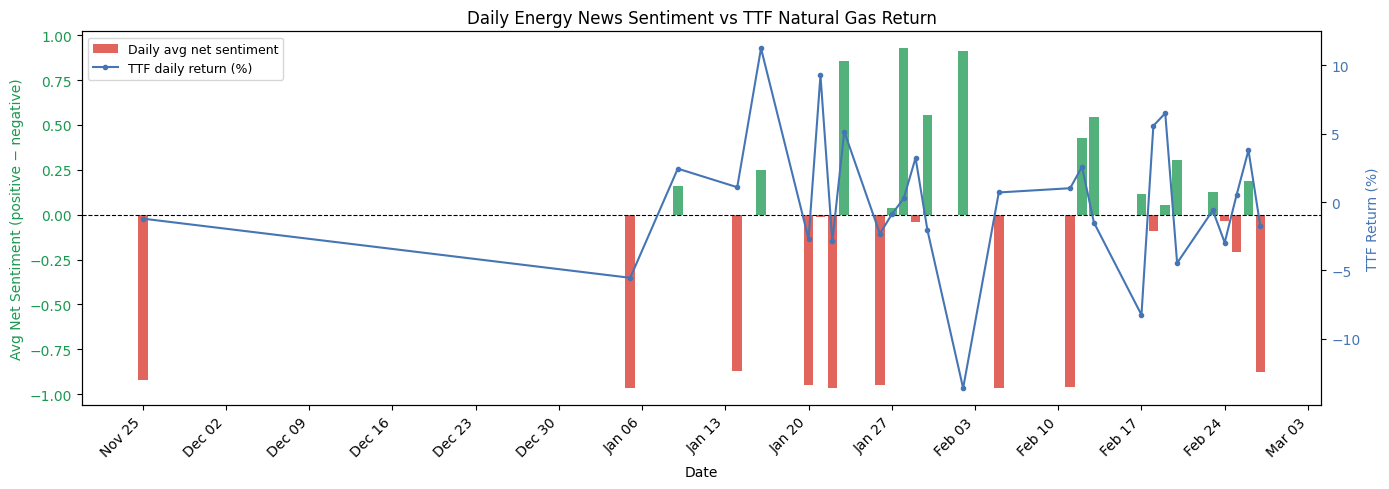

Saved: output/sentiment_vs_price.png


In [ ]:
# Plot 1: Daily sentiment bar chart + price return line (dual y-axis)
df_plot = df_merged.dropna(subset=['avg_sentiment', 'return_pct']).copy()
df_plot['date_dt'] = pd.to_datetime(df_plot['date'])

fig, ax1 = plt.subplots(figsize=(14, 5))

colors = ['#d73027' if v < 0 else '#1a9850' for v in df_plot['avg_sentiment']]
ax1.bar(df_plot['date_dt'], df_plot['avg_sentiment'],
        color=colors, alpha=0.75, label='Daily avg net sentiment', zorder=2)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Date')
ax1.set_ylabel('Avg Net Sentiment (positive − negative)', color='#1a9850')
ax1.tick_params(axis='y', labelcolor='#1a9850')

ax2 = ax1.twinx()
ax2.plot(df_plot['date_dt'], df_plot['return_pct'],
         color='#4575b4', linewidth=1.5, marker='o', markersize=3,
         label='TTF daily return (%)', zorder=3)
ax2.set_ylabel('TTF Return (%)', color='#4575b4')
ax2.tick_params(axis='y', labelcolor='#4575b4')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Daily Energy News Sentiment vs TTF Natural Gas Return')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_vs_price.png', dpi=150)
plt.show()
print('Saved: output/sentiment_vs_price.png')

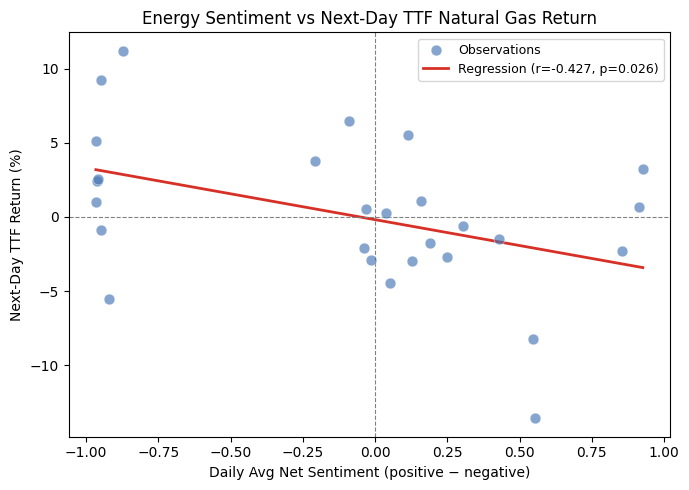

Saved: output/sentiment_vs_nextday_return.png


In [ ]:
# Plot 2: Scatter — avg_sentiment vs next-day return with regression line
df_scatter = df_merged.dropna(subset=['avg_sentiment', 'next_day_return']).copy()

x = df_scatter['avg_sentiment'].values
y = df_scatter['next_day_return'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.65, edgecolors='white', linewidth=0.4,
           color='#4575b4', s=60, label='Observations', zorder=3)
ax.plot(x_line, y_line, color='#d73027', linewidth=2,
        label=f'Regression (r={r_value:.3f}, p={p_value:.3f})')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Daily Avg Net Sentiment (positive − negative)')
ax.set_ylabel('Next-Day TTF Return (%)')
ax.set_title('Energy Sentiment vs Next-Day TTF Natural Gas Return')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_vs_nextday_return.png', dpi=150)
plt.show()
print('Saved: output/sentiment_vs_nextday_return.png')

## Summary

In [ ]:
date_range_start = df_merged['date'].min()
date_range_end   = df_merged['date'].max()

print('=' * 55)
print('ENERGY NEWS SENTIMENT PIPELINE — SUMMARY')
print('=' * 55)
print(f'Articles fetched (all topics)  : {len(all_raw)}')
print(f'Articles passing energy filter : {len(energy_articles)}')
print(f'Date range covered             : {date_range_start} to {date_range_end}')
print(f'Days with merged data          : {len(df_merged)}')
print(f'Correlation (sentiment / same-day return)   : {r_sameday:+.4f}')
print(f'Correlation (sentiment / next-day return)   : {r_nextday:+.4f}')
print('=' * 55)

if abs(r_nextday) > abs(r_sameday):
    print('=> Sentiment has STRONGER predictive correlation with next-day returns.')
else:
    print('=> Sentiment has STRONGER (or equal) correlation with same-day returns.')

ENERGY NEWS SENTIMENT PIPELINE — SUMMARY
Articles fetched (all topics)  : 156
Articles passing energy filter : 93
Date range covered             : 2025-11-25 to 2026-02-27
Days with merged data          : 28
Correlation (sentiment / same-day return)   : +0.0645
Correlation (sentiment / next-day return)   : -0.4274
=> Sentiment has STRONGER predictive correlation with next-day returns.


# More advanced sentiment analysis pipeline

## Step 1 — Load Synthetic Futures Price Data

In [2]:
# ── Step 1: Load Synthetic Futures Price Data ─────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Path auto-detection — works in Colab (after %cd in cell 2) and locally.
_csv_candidates = [
    Path('sentiment_analysis/data/synthetic_power_futures_15min.csv'),  # Colab
    Path('data/synthetic_power_futures_15min.csv'),
    Path('POC/sentiment_analysis/data/synthetic_power_futures_15min.csv'),
]
FUTURES_CSV = next((p for p in _csv_candidates if p.exists()), _csv_candidates[0])
print(f"Loading futures data from: {FUTURES_CSV}")

df_futures = (
    pd.read_csv(FUTURES_CSV, parse_dates=['timestamp'])
    .set_index('timestamp')
    .sort_index()
    [['open', 'high', 'low', 'close']]
)

DATE_START = df_futures.index.min()
DATE_END   = df_futures.index.max()

print(f"Bars loaded  : {len(df_futures):,}")
print(f"Date range   : {DATE_START}  to  {DATE_END}")
df_futures.head()

Loading futures data from: sentiment_analysis/data/synthetic_power_futures_15min.csv
Bars loaded  : 35,136
Date range   : 2025-03-02 00:00:00  to  2026-03-02 23:45:00


,open,high,low,close
timestamp,,,,
2025-03-02 00:00:00,44.93,45.03,44.93,45.00
2025-03-02 00:15:00,45.26,45.26,45.17,45.20
2025-03-02 00:30:00,44.92,45.06,44.74,44.88
2025-03-02 00:45:00,45.17,45.27,44.97,45.20
2025-03-02 01:00:00,46.16,46.26,46.07,46.21


## Step 2 — News Headlines with Timestamps

In [3]:
# ── Step 2: Fetch real news or generate synthetic headlines ───────────────────
#
# Strategy:
#   1. Try several energy-focused RSS feeds; extract headlines with timestamps
#      that overlap the futures date range.
#   2. If >= 1 000 such headlines found  →  use them  (NEWS_SOURCE = 'rss')
#   3. Otherwise generate 1 000 synthetic headlines spread over the date range,
#      then prepend any real RSS headlines as bonus data.
#
# OUTPUT  df_news      DataFrame with columns [timestamp, headline]
#         NEWS_SOURCE  'rss' | 'synthetic'
#
# To swap in real news later: replace df_news here with any DataFrame of the
# same schema and re-run Steps 3-7 unchanged.

import feedparser   # already installed in the notebook environment

TARGET_HEADLINES = 1_000

ENERGY_KEYWORDS_NEWS = [
    'energy', 'power', 'electricity', 'natural gas', 'lng', 'wind', 'solar',
    'grid', 'storage', 'demand', 'supply', 'crude', 'oil', 'carbon', 'ttf',
    'eex', 'nord pool', 'nuclear', 'coal', 'pipeline', 'import', 'export',
    'weather', 'storm', 'drought', 'freeze', 'heatwave', 'capacity', 'outage',
]

RSS_FEEDS_ADVANCED = [
    'https://www.eia.gov/rss/todayinenergy.xml',
    'https://oilprice.com/rss/main',
    'https://www.energymonitor.ai/feed/',
    'https://www.rigzone.com/news/rss/rigzone_latest.aspx',
    'https://www.theguardian.com/environment/energy/rss',
    'https://feeds.reuters.com/reuters/companyNews',
    'https://www.carbonbrief.org/feed',
    'https://feeds.bbci.co.uk/news/business/rss.xml',
]


def _parse_rss_ts(entry):
    for attr in ('published_parsed', 'updated_parsed'):
        t = getattr(entry, attr, None)
        if t:
            try:
                return pd.Timestamp(datetime(*t[:6]))
            except Exception:
                pass
    return None


def _is_energy(text):
    low = text.lower()
    return any(kw in low for kw in ENERGY_KEYWORDS_NEWS)


def try_fetch_rss(feeds, date_start, date_end):
    results, seen = [], set()
    window_end = date_end + pd.Timedelta(days=30)
    for url in feeds:
        try:
            feed = feedparser.parse(url)
            for e in feed.entries:
                ts    = _parse_rss_ts(e)
                title = (getattr(e, 'title', '') or '').strip()
                if not ts or not title or title in seen:
                    continue
                if not (date_start <= ts <= window_end):
                    continue
                combined = title + ' ' + (getattr(e, 'summary', '') or '')
                if _is_energy(combined):
                    seen.add(title)
                    results.append((ts, title))
        except Exception as exc:
            print(f"  [WARN] {url}: {exc}")
    return sorted(results, key=lambda x: x[0])


# ── Attempt RSS fetch ─────────────────────────────────────────────────────────
print("Attempting RSS fetch...")
rss_results = try_fetch_rss(RSS_FEEDS_ADVANCED, DATE_START, DATE_END)
print(f"  Energy headlines in date range: {len(rss_results):,}")

if len(rss_results) >= TARGET_HEADLINES:
    df_news = (
        pd.DataFrame(rss_results[:TARGET_HEADLINES], columns=['timestamp', 'headline'])
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    NEWS_SOURCE = 'rss'
    print(f"Using {len(df_news):,} real RSS headlines.")

else:
    # ── Generate synthetic headlines ──────────────────────────────────────────
    print(f"Insufficient RSS data ({len(rss_results)} < {TARGET_HEADLINES}).")
    print("Generating synthetic energy headlines...")

    _TEMPLATES = [
        # Supply disruptions
        "Unplanned outage at {plant} power plant cuts capacity by {mw} MW",
        "Pipeline disruption in {region} tightens gas supply outlook",
        "LNG terminal at {port} halts exports due to technical issues",
        "Unexpected shutdown at {plant} nuclear unit raises supply concerns",
        "Gas compressor failure at {hub} hub reduces throughput by {pct}%",
        "Maintenance works on {plant} interconnector limits cross-border flows",
        # Storage
        "European gas storage falls to {pct}% capacity, below seasonal norm",
        "Storage injection season begins; cavern fill rate lagging at {pct}%",
        "Gas storage at {hub} hub hits multi-year low of {vol} TWh",
        "Underground storage at {pct}% signals tight Q{q} supply buffer",
        "Record storage withdrawal rate as temperatures plunge in {region}",
        "Storage operators in {region} warn of supply crunch if winter prolonged",
        # Weather
        "Polar vortex over {region} set to spike heating demand by {pct}%",
        "Storm {storm_name} disrupts North Sea wind output; grid warns of shortfall",
        "Extended drought cuts hydro output in {region}, boosting gas burn",
        "Heatwave across {region} pushes electricity demand to seasonal record",
        "Cold snap in {region} drives heating demand {pct}% above five-year average",
        "Fog reduces solar generation across {region} by an estimated {pct}%",
        # LNG
        "LNG cargo from {country} diverted to Asia as spot prices surge {pct}%",
        "US LNG exports hit record {vol} bcf/day on strong European demand",
        "Qatar ships additional {vol} LNG cargoes to Europe ahead of winter peak",
        "New LNG import terminal in {region} receives first cargo",
        "LNG spot price spikes to {price} USD/mmBtu on tight supply signals",
        "Floating LNG vessel at {port} deployed to ease European import bottleneck",
        # Demand
        "IEA revises European power demand forecast up {pct}% for Q{q} {year}",
        "Industrial energy demand in {region} contracts {pct}% on weak output",
        "Electrification of heating drives {pct}% rise in winter electricity load",
        "Data centres in {region} to add {mw} MW to baseload demand by year-end",
        "Mild autumn tempers gas demand; forecast lowered by {vol} bcm",
        "AI infrastructure boom lifts {region} baseload power demand by {pct}%",
        # Renewable / generation mix
        "Solar generation in {region} sets record at {mw} MW peak output",
        "Wind curtailment rises in {region} as grid operator caps surplus output",
        "Renewable penetration hits {pct}% share of {region} generation mix",
        "Offshore wind farm {plant} commissions {mw} MW, boosting capacity",
        "Grid balancing costs rise {pct}% as wind intermittency increases",
        "Low-wind week in {region} forces restart of mothballed gas plant",
        # Policy / market
        "Carbon price surges {pct}% as EU tightens ETS allowance supply",
        "EUA futures breach {price} EUR/t amid stricter emissions cap expectations",
        "Government auction awards {mw} MW of offshore wind to {company}",
        "Regulator approves {pct}% increase in electricity network tariffs",
        "Power market reform reshapes {region} capacity market rules",
        "Windfall tax on energy producers sparks investor concerns in {region}",
        # Geopolitical
        "Supply uncertainty grows as transit agreement for {region} gas expires",
        "Analysts warn of {pct}% price upside if Russia-Ukraine transit disrupted",
        "Sanctions on {country} LNG raise supply risk for European importers",
    ]

    _FILLS = {
        'plant':      ['Drax', 'Sizewell B', 'Eemshaven', 'Kozloduy', 'Dukovany', 'Flamanville'],
        'port':       ['Rotterdam', 'Zeebrugge', 'Sabine Pass', 'Freeport', 'Montoir', 'Gate'],
        'hub':        ['TTF', 'NBP', 'THE', 'NCG', 'Gaspool', 'PSV', 'ZTP'],
        'region':     ['Northwest Europe', 'Central Europe', 'Iberia', 'Nordics',
                       'Southeast Europe', 'UK', 'Germany', 'France', 'Benelux'],
        'country':    ['Qatar', 'USA', 'Australia', 'Nigeria', 'Norway', 'Algeria'],
        'storm_name': ['Ciaran', 'Babet', 'Domingos', 'Pia', 'Lilian', 'Darragh'],
        'company':    ['Vattenfall', 'RWE', 'Orsted', 'EDP Renewables', 'Equinor', 'BP'],
        'year':       ['2025', '2026'],
        'q':          ['1', '2', '3', '4'],
        'mw':         ['200', '450', '800', '1200', '2400', '4500'],
        'vol':        ['2.1', '4.8', '12', '38', '100'],
        'pct':        ['3', '7', '12', '18', '25', '35'],
        'price':      ['11.50', '13.80', '42', '58', '75'],
    }

    rng = np.random.default_rng(42)

    def _make_headline():
        tmpl = _TEMPLATES[rng.integers(len(_TEMPLATES))]
        for key, choices in _FILLS.items():
            tmpl = tmpl.replace(f'{{{key}}}', rng.choice(choices))
        return tmpl

    # Sample timestamps from trading-hours bars (07:00-22:00) across full range
    trading_bars = df_futures.index[
        (df_futures.index.hour >= 7) & (df_futures.index.hour < 22)
    ]
    sampled_ts = pd.DatetimeIndex(
        rng.choice(trading_bars, size=TARGET_HEADLINES, replace=True)
    ).sort_values()

    df_news = pd.DataFrame({
        'timestamp': sampled_ts,
        'headline':  [_make_headline() for _ in range(TARGET_HEADLINES)],
    })

    if rss_results:
        df_rss_bonus = pd.DataFrame(rss_results, columns=['timestamp', 'headline'])
        df_news = (
            pd.concat([df_news, df_rss_bonus])
            .sort_values('timestamp')
            .reset_index(drop=True)
        )
        print(f"  Prepended {len(rss_results)} real RSS headlines as bonus data.")

    NEWS_SOURCE = 'synthetic'

print(f"News DataFrame  : {len(df_news):,} headlines  (source: {NEWS_SOURCE})")
print(f"Timestamp range : {df_news['timestamp'].min()}  to  {df_news['timestamp'].max()}")
df_news.head()

Attempting RSS fetch...
  Energy headlines in date range: 105
Insufficient RSS data (105 < 1000).
Generating synthetic energy headlines...
  Prepended 105 real RSS headlines as bonus data.
News DataFrame  : 1,105 headlines  (source: synthetic)
Timestamp range : 2025-03-03 16:00:00  to  2026-03-02 17:00:00


,timestamp,headline
0,2025-03-03 16:00:00,Carbon price surges 7% as EU tightens ETS allo...
1,2025-03-03 18:45:00,Floating LNG vessel at Sabine Pass deployed to...
2,2025-03-03 21:00:00,Industrial energy demand in Germany contracts ...
3,2025-03-03 21:45:00,LNG cargo from Nigeria diverted to Asia as spo...
4,2025-03-04 07:00:00,Qatar ships additional 38 LNG cargoes to Europ...


## Step 3 — Price Impact Labeling

In [4]:
# ── Step 3: Price Impact Labeling ─────────────────────────────────────────────
#
# For each headline:
#   - Floor-match to the last 15-min bar at or before the headline timestamp.
#   - Look up close prices at T, T+15 min, T+30 min, T+60 min.
#   - Compute % price changes → return_15min, return_30min, return_60min.
#
# These are the ground-truth labels the model will later be trained to predict.
# Rows where a forward bar is missing (market closed) are kept with NaN returns.


def label_price_impact(df_news, df_futures):
    fut_idx   = df_futures.index
    close_ser = df_futures['close']
    rows = []

    for ts, headline in zip(df_news['timestamp'], df_news['headline']):
        ts = pd.Timestamp(ts)

        loc = fut_idx.searchsorted(ts, side='right') - 1
        if loc < 0:
            continue

        bar_ts  = fut_idx[loc]
        price_t = close_ser.iat[loc]

        ts_15 = bar_ts + pd.Timedelta(minutes=15)
        ts_30 = bar_ts + pd.Timedelta(minutes=30)
        ts_60 = bar_ts + pd.Timedelta(minutes=60)

        p15 = close_ser.get(ts_15)
        p30 = close_ser.get(ts_30)
        p60 = close_ser.get(ts_60)

        rows.append({
            'timestamp':    ts,
            'headline':     headline,
            'bar_ts':       bar_ts,
            'price_t':      price_t,
            'price_t15':    p15,
            'price_t30':    p30,
            'price_t60':    p60,
            'return_15min': (p15 / price_t - 1) * 100 if p15 is not None else np.nan,
            'return_30min': (p30 / price_t - 1) * 100 if p30 is not None else np.nan,
            'return_60min': (p60 / price_t - 1) * 100 if p60 is not None else np.nan,
        })

    df_labeled = pd.DataFrame(rows).reset_index(drop=True)

    print("Valid price labels per window:")
    n_total = len(df_labeled)
    for col in ('return_15min', 'return_30min', 'return_60min'):
        n_valid = df_labeled[col].notna().sum()
        print(f"  {col}: {n_valid:,} / {n_total:,}  ({n_valid/n_total:.1%})")

    return df_labeled


print("Labeling price impact...")
df_labeled = label_price_impact(df_news, df_futures)
print(f"Labeled DataFrame shape: {df_labeled.shape}")
df_labeled[['timestamp', 'headline', 'price_t',
            'return_15min', 'return_30min', 'return_60min']].head()

Labeling price impact...
Valid price labels per window:
  return_15min: 1,105 / 1,105  (100.0%)
  return_30min: 1,105 / 1,105  (100.0%)
  return_60min: 1,105 / 1,105  (100.0%)
Labeled DataFrame shape: (1105, 10)


,timestamp,headline,price_t,return_15min,return_30min,return_60min
0,2025-03-03 16:00:00,Carbon price surges 7% as EU tightens ETS allo...,51.67,-1.412812,-0.058061,0.696729
1,2025-03-03 18:45:00,Floating LNG vessel at Sabine Pass deployed to...,53.82,-1.189149,-1.244890,-0.185805
2,2025-03-03 21:00:00,Industrial energy demand in Germany contracts ...,57.10,0.175131,-1.751313,-3.712785
3,2025-03-03 21:45:00,LNG cargo from Nigeria diverted to Asia as spo...,54.89,0.163964,-0.692294,0.000000
4,2025-03-04 07:00:00,Qatar ships additional 38 LNG cargoes to Europ...,50.97,3.531489,0.333530,-1.392976


## Step 4 — FinBERT Sentiment Scoring

In [5]:
# ── Step 4: FinBERT Sentiment Scoring ─────────────────────────────────────────
#
# Load ProsusAI/finbert (reuses the pipeline already in memory if present).
# Adds columns to the labeled DataFrame:
#   finbert_label  — 'positive' | 'negative' | 'neutral'
#   finbert_score  — confidence of the predicted label  (0 to 1)

!pip install -q transformers torch

import torch
from transformers import pipeline as hf_pipeline

if 'finbert' not in dir() or finbert is None:
    _device = 0 if torch.cuda.is_available() else -1
    print(f"Loading ProsusAI/finbert on {'GPU' if _device == 0 else 'CPU'}...")
    finbert = hf_pipeline(
        'text-classification',
        model='ProsusAI/finbert',
        top_k=1,
        truncation=True,
        max_length=512,
        device=_device,
    )
    print("Model loaded.")
else:
    print("Reusing existing FinBERT pipeline.")


def score_headlines_finbert(headlines, batch_size=64):
    results = []
    n = len(headlines)
    for i in range(0, n, batch_size):
        batch = [h[:512] for h in headlines[i:i + batch_size]]
        preds = finbert(batch)
        for pred in preds:
            top = pred[0]
            results.append({'finbert_label': top['label'], 'finbert_score': top['score']})
        if i % (batch_size * 5) == 0:
            print(f"  Scored {min(i + batch_size, n):,} / {n:,}")
    return results


print(f"Scoring {len(df_labeled):,} headlines...")
scores = score_headlines_finbert(df_labeled['headline'].tolist())

df_scored_adv = df_labeled.copy()
df_scored_adv['finbert_label'] = [s['finbert_label'] for s in scores]
df_scored_adv['finbert_score'] = [s['finbert_score'] for s in scores]

print(f"Label distribution:")
print(df_scored_adv['finbert_label'].value_counts().to_string())
df_scored_adv[['headline', 'finbert_label', 'finbert_score',
               'return_15min', 'return_30min', 'return_60min']].head()

Loading ProsusAI/finbert on GPU...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded.
Scoring 1,105 headlines...
  Scored 64 / 1,105
  Scored 384 / 1,105


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Scored 704 / 1,105
  Scored 1,024 / 1,105
Label distribution:
finbert_label
negative    610
positive    385
neutral     110


,headline,finbert_label,finbert_score,return_15min,return_30min,return_60min
0,Carbon price surges 7% as EU tightens ETS allo...,positive,0.867754,-1.412812,-0.058061,0.696729
1,Floating LNG vessel at Sabine Pass deployed to...,positive,0.906250,-1.189149,-1.244890,-0.185805
2,Industrial energy demand in Germany contracts ...,negative,0.974966,0.175131,-1.751313,-3.712785
3,LNG cargo from Nigeria diverted to Asia as spo...,positive,0.920311,0.163964,-0.692294,0.000000
4,Qatar ships additional 38 LNG cargoes to Europ...,positive,0.609834,3.531489,0.333530,-1.392976


## Step 5 — Signal Alignment Analysis

In [6]:
# ── Step 5: Signal Alignment Analysis ─────────────────────────────────────────
#
# Directional agreement:
#   positive  →  predicts price RISE    (return > 0)
#   negative  →  predicts price FALL    (return < 0)
#   neutral   →  excluded (no directional claim)
#
# Directional accuracy = fraction where FinBERT direction == sign(return).

LABEL_DIR = {'positive': 1, 'negative': -1}


def directional_accuracy(df, return_col):
    sub = (
        df[df['finbert_label'].isin(LABEL_DIR)]
        .dropna(subset=[return_col])
        .copy()
    )
    if len(sub) == 0:
        return np.nan, 0
    pred_dir   = sub['finbert_label'].map(LABEL_DIR)
    actual_dir = np.sign(sub[return_col])
    return (pred_dir == actual_dir).mean(), len(sub)


WINDOWS = {
    'T+15 min': 'return_15min',
    'T+30 min': 'return_30min',
    'T+60 min': 'return_60min',
}

accuracy_results = {}
hdr = f"{'Window':<12}  {'N (non-neutral)':>16}  {'Dir. Accuracy':>14}  {'vs 50% Baseline':>16}"
print(hdr)
print("-" * len(hdr))

for label, col in WINDOWS.items():
    acc, n = directional_accuracy(df_scored_adv, col)
    vs_base = acc - 0.50
    accuracy_results[label] = {'accuracy': acc, 'n': n, 'vs_baseline': vs_base, 'col': col}
    sign = '+' if vs_base >= 0 else ''
    print(f"{label:<12}  {n:>16,}  {acc:>13.1%}  {sign}{vs_base:>14.1%}")

print("-" * len(hdr))
print("  Baseline = 50% (random directional guess on binary outcome)")

Window         N (non-neutral)   Dir. Accuracy   vs 50% Baseline
----------------------------------------------------------------
T+15 min                   995          47.8%           -2.2%
T+30 min                   995          46.3%           -3.7%
T+60 min                   995          46.4%           -3.6%
----------------------------------------------------------------
  Baseline = 50% (random directional guess on binary outcome)


## Step 6 — Visualisation

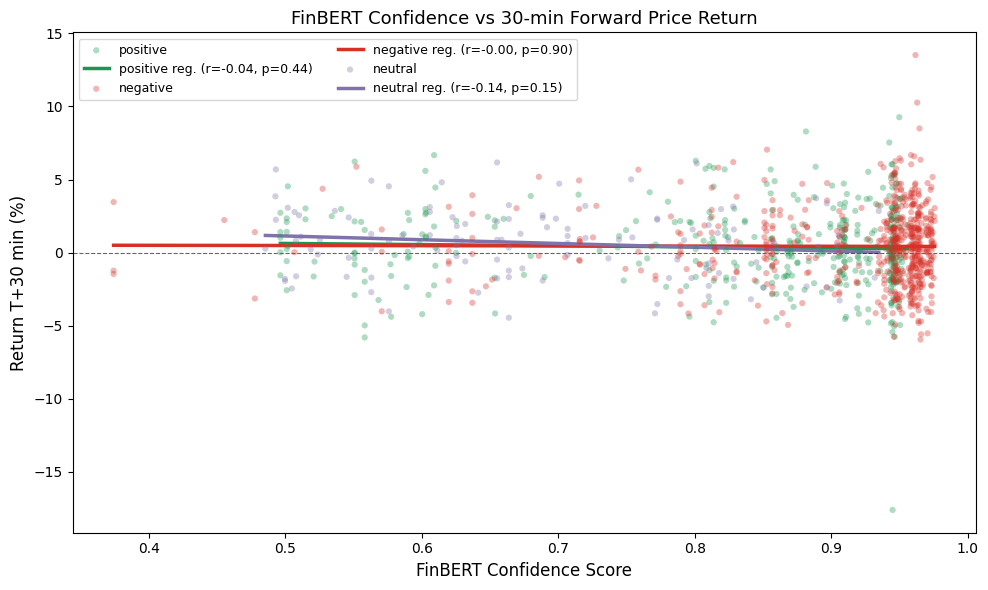

Saved: output/adv_finbert_scatter_return30.png


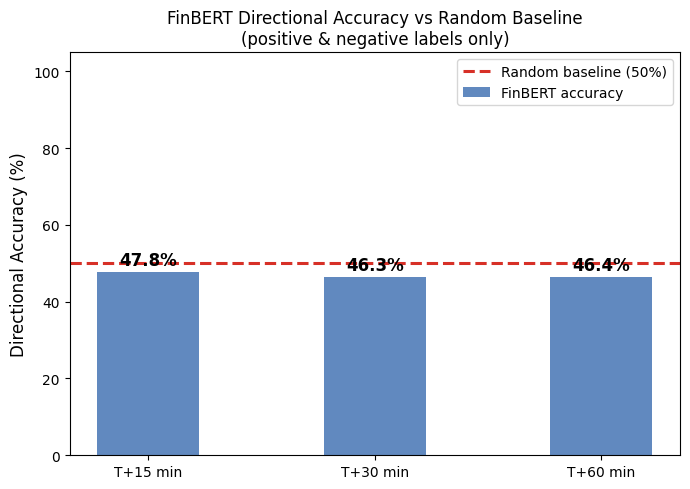

Saved: output/adv_directional_accuracy.png


In [7]:
# ── Step 6: Visualisation ─────────────────────────────────────────────────────
#
# Plot 1: Scatter of finbert_score vs return_30min, coloured by label,
#         with a per-class linear regression line.
# Plot 2: Bar chart of directional accuracy at T+15/30/60 vs 50% baseline.

from scipy import stats as sp_stats

OUTPUT_ADV = Path('output')
OUTPUT_ADV.mkdir(exist_ok=True)

LABEL_COLORS = {'positive': '#1a9850', 'negative': '#d73027', 'neutral': '#8073ac'}

# ── Plot 1 ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for lbl in ['positive', 'negative', 'neutral']:
    sub = df_scored_adv[df_scored_adv['finbert_label'] == lbl].dropna(subset=['return_30min'])
    if len(sub) < 3:
        continue
    x, y = sub['finbert_score'].values, sub['return_30min'].values
    ax.scatter(x, y, color=LABEL_COLORS[lbl], label=lbl,
               alpha=0.35, s=20, edgecolors='none', zorder=3)
    slope, intercept, r_val, p_val, _ = sp_stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept,
            color=LABEL_COLORS[lbl], linewidth=2.5,
            label=f'{lbl} reg. (r={r_val:.2f}, p={p_val:.2f})')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('FinBERT Confidence Score', fontsize=12)
ax.set_ylabel('Return T+30 min (%)', fontsize=12)
ax.set_title('FinBERT Confidence vs 30-min Forward Price Return', fontsize=13)
ax.legend(fontsize=9, ncol=2, loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_ADV / 'adv_finbert_scatter_return30.png', dpi=150)
plt.show()
print("Saved: output/adv_finbert_scatter_return30.png")

# ── Plot 2 ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

window_labels  = list(accuracy_results.keys())
accuracies_pct = [accuracy_results[k]['accuracy'] * 100 for k in window_labels]

bars = ax.bar(window_labels, accuracies_pct,
              color='#4575b4', alpha=0.85, width=0.45, label='FinBERT accuracy')
ax.axhline(50, color='#d73027', linewidth=2.2, linestyle='--',
           label='Random baseline (50%)')

for bar, val in zip(bars, accuracies_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel('Directional Accuracy (%)', fontsize=12)
ax.set_title('FinBERT Directional Accuracy vs Random Baseline\n(positive & negative labels only)',
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_ADV / 'adv_directional_accuracy.png', dpi=150)
plt.show()
print("Saved: output/adv_directional_accuracy.png")

## Step 7 — Summary

In [8]:
# ── Step 7: Summary Output ─────────────────────────────────────────────────────
#
# Prints: headline count, label distribution, directional accuracy per window,
# and a one-line interpretation of the results.
#
# ── HOW TO USE WITH REAL DATA ─────────────────────────────────────────────────
# Replace df_news in Step 2 with any DataFrame having columns:
#     timestamp  (pd.Timestamp, timezone-naive)
#     headline   (str)
# Then re-run Steps 3-7 unchanged.
# ──────────────────────────────────────────────────────────────────────────────

label_counts = df_scored_adv['finbert_label'].value_counts()
n_headlines  = len(df_scored_adv)

SEP = "=" * 62
print(SEP)
print("  FINBERT x PRICE IMPACT  --  ADVANCED PIPELINE SUMMARY")
print(SEP)
print(f"  News source          : {NEWS_SOURCE}")
print(f"  Headlines analysed   : {n_headlines:,}")
print(f"  Label distribution   : "
      f"positive={label_counts.get('positive', 0):,}  "
      f"negative={label_counts.get('negative', 0):,}  "
      f"neutral={label_counts.get('neutral', 0):,}")
print()
print(f"  {'Window':<12}  {'N (non-neutral)':>16}  {'Dir. Accuracy':>14}  {'vs Baseline':>12}")
print(f"  {'-'*12}  {'-'*16}  {'-'*14}  {'-'*12}")

for label, vals in accuracy_results.items():
    sign = '+' if vals['vs_baseline'] >= 0 else ''
    print(f"  {label:<12}  {vals['n']:>16,}  {vals['accuracy']:>13.1%}  "
          f"{sign}{vals['vs_baseline']:>10.1%}")

print(SEP)

# One-line interpretation
best_w   = max(accuracy_results, key=lambda k: accuracy_results[k]['accuracy'])
best_acc = accuracy_results[best_w]['accuracy']
above_50 = [k for k, v in accuracy_results.items() if v['accuracy'] > 0.50]

if len(above_50) == len(accuracy_results):
    _interp = (f"FinBERT shows above-chance directional alignment across ALL windows "
               f"(best: {best_w} at {best_acc:.1%}), suggesting a detectable signal.")
elif best_acc > 0.55:
    _interp = (f"FinBERT shows partial alignment, strongest at {best_w} ({best_acc:.1%}); "
               f"a weak but potentially exploitable directional signal.")
else:
    _interp = (f"FinBERT does not consistently beat 50% baseline (best: {best_w} at "
               f"{best_acc:.1%}). With {NEWS_SOURCE} data this is expected -- "
               f"replace df_news with real timestamped headlines and re-run.")

print(f"\n  Interpretation: {_interp}")
print(SEP)

  FINBERT x PRICE IMPACT  --  ADVANCED PIPELINE SUMMARY
  News source          : synthetic
  Headlines analysed   : 1,105
  Label distribution   : positive=385  negative=610  neutral=110

  Window         N (non-neutral)   Dir. Accuracy   vs Baseline
  ------------  ----------------  --------------  ------------
  T+15 min                   995          47.8%       -2.2%
  T+30 min                   995          46.3%       -3.7%
  T+60 min                   995          46.4%       -3.6%

  Interpretation: FinBERT does not consistently beat 50% baseline (best: T+15 min at 47.8%). With synthetic data this is expected -- replace df_news with real timestamped headlines and re-run.
